# Week 5 - Trust & Safety Pipeline & Final Results
## Adversarial Robustness Testing & Trust Safety Pipeline

## Step 1 - Imports

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import cv2

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print("All imports successful.")


Device  : cpu
PyTorch : 2.8.0+cpu
All imports successful.


## Step 2 - Configuration

In [2]:
PROJECT_DIR      = Path(r"C:/adversarial_doc_project")
DATA_DIR         = PROJECT_DIR / "data"
SPLITS_DIR       = DATA_DIR / "splits"
OUTPUTS_DIR      = PROJECT_DIR / "outputs"
CHECKPOINTS_DIR  = PROJECT_DIR / "checkpoints"

IMG_SIZE     = 224
NUM_CLASSES  = 3
NUM_WORKERS  = 0
CLASS_LIST   = ["real", "benign", "malicious"]
CLASS_NAMES  = {0: "real", 1: "benign", 2: "malicious"}

HARDENED_EFFNET_PATH = CHECKPOINTS_DIR / "hardened_efficientnet_best.pth"
HARDENED_RESNET_PATH = CHECKPOINTS_DIR / "hardened_resnet18_best.pth"

assert HARDENED_EFFNET_PATH.exists(), "Hardened EfficientNet not found. Run Week 4."
assert HARDENED_RESNET_PATH.exists(), "Hardened ResNet18 not found. Run Week 4."

print("Configuration ready.")
print(f"Project dir : {PROJECT_DIR}")


Configuration ready.
Project dir : C:\adversarial_doc_project


## Step 3 - Load Hardened EfficientNet-B0

In [3]:
def build_efficientnet(num_classes=3):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model   = models.efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

effnet = build_efficientnet(num_classes=NUM_CLASSES)
ckpt   = torch.load(HARDENED_EFFNET_PATH, map_location=DEVICE, weights_only=True)
effnet.load_state_dict(ckpt["model_state"])
effnet = effnet.to(DEVICE)
effnet.eval()
print(f"EfficientNet-B0 loaded from epoch {ckpt['epoch']}")
print(f"Best val accuracy: {ckpt['val_acc']:.4f}")


EfficientNet-B0 loaded from epoch 10
Best val accuracy: 0.9819


## Step 4 - Trust & Safety Pipeline

In [4]:
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

THRESHOLD_APPROVE          = 0.85
THRESHOLD_MALICIOUS_REJECT = 0.50
THRESHOLD_BENIGN_WARN      = 0.40


def trust_safety_pipeline(image_path, model, transform, device):
    img    = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1)[0]

    conf_real      = probs[0].item()
    conf_benign    = probs[1].item()
    conf_malicious = probs[2].item()
    pred_class     = int(probs.argmax().item())
    max_conf       = float(probs.max().item())

    if conf_malicious >= THRESHOLD_MALICIOUS_REJECT:
        decision = "REJECT"
        risk     = "HIGH"
        reason   = (f"Document shows signs of malicious tampering "
                    f"(confidence: {conf_malicious:.1%}). "
                    f"Possible face swap or text field alteration detected.")
    elif conf_real >= THRESHOLD_APPROVE:
        decision = "APPROVE"
        risk     = "LOW"
        reason   = (f"Document appears genuine "
                    f"(confidence: {conf_real:.1%}). "
                    f"No signs of tampering detected.")
    elif conf_benign >= THRESHOLD_BENIGN_WARN:
        decision = "APPROVE WITH WARNING"
        risk     = "MEDIUM"
        reason   = (f"Document likely genuine but image quality is poor "
                    f"(confidence: {conf_benign:.1%}). "
                    f"Possible blur, rotation, or lighting issue.")
    else:
        decision = "HUMAN REVIEW"
        risk     = "UNCERTAIN"
        reason   = (f"Model uncertain about this document "
                    f"(max confidence: {max_conf:.1%}). "
                    f"Manual review required.")

    return {
        "predicted_class"     : pred_class,
        "predicted_label"     : CLASS_NAMES[pred_class],
        "confidence_real"     : round(conf_real, 4),
        "confidence_benign"   : round(conf_benign, 4),
        "confidence_malicious": round(conf_malicious, 4),
        "max_confidence"      : round(max_conf, 4),
        "risk_level"          : risk,
        "decision"            : decision,
        "reason"              : reason,
    }


print("Trust & Safety pipeline defined.")
print(f"Thresholds:")
print(f"  APPROVE           : real >= {THRESHOLD_APPROVE}")
print(f"  APPROVE WITH WARN : benign >= {THRESHOLD_BENIGN_WARN}")
print(f"  REJECT            : malicious >= {THRESHOLD_MALICIOUS_REJECT}")
print(f"  HUMAN REVIEW      : all others")


Trust & Safety pipeline defined.
Thresholds:
  APPROVE           : real >= 0.85
  APPROVE WITH WARN : benign >= 0.4
  REJECT            : malicious >= 0.5
  HUMAN REVIEW      : all others


## Step 5 - Test Pipeline on Sample Documents

In [5]:
aug_test = pd.read_csv(SPLITS_DIR / "aug_test.csv")

samples = {}
for _, row in aug_test.iterrows():
    label = int(row["label"])
    if label not in samples:
        samples[label] = row["frame_path"]
    if len(samples) == 3:
        break

print("Trust & Safety Pipeline -- Sample Decisions")
print("=" * 70)

for class_idx in range(3):
    img_path = samples[class_idx]
    result   = trust_safety_pipeline(img_path, effnet, val_transform, DEVICE)

    print(f"\nInput: {CLASS_NAMES[class_idx].upper()} document")
    print(f"  Predicted  : {result['predicted_label']}")
    print(f"  Confidence : real={result['confidence_real']:.3f}, "
          f"benign={result['confidence_benign']:.3f}, "
          f"malicious={result['confidence_malicious']:.3f}")
    print(f"  Risk Level : {result['risk_level']}")
    print(f"  Decision   : {result['decision']}")
    print(f"  Reason     : {result['reason']}")
    print("-" * 70)


Trust & Safety Pipeline -- Sample Decisions

Input: REAL document
  Predicted  : real
  Confidence : real=1.000, benign=0.000, malicious=0.000
  Risk Level : LOW
  Decision   : APPROVE
  Reason     : Document appears genuine (confidence: 100.0%). No signs of tampering detected.
----------------------------------------------------------------------

Input: BENIGN document
  Predicted  : benign
  Confidence : real=0.000, benign=1.000, malicious=0.000
  Risk Level : MEDIUM
  Decision   : APPROVE WITH WARNING
  Reason     : Document likely genuine but image quality is poor (confidence: 100.0%). Possible blur, rotation, or lighting issue.
----------------------------------------------------------------------

Input: MALICIOUS document
  Predicted  : malicious
  Confidence : real=0.000, benign=0.000, malicious=1.000
  Risk Level : HIGH
  Decision   : REJECT
  Reason     : Document shows signs of malicious tampering (confidence: 100.0%). Possible face swap or text field alteration detected.
-

## Step 6 - Full Pipeline Evaluation on Test Set

In [6]:
class DocumentDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row["label"])
        img   = Image.open(row["frame_path"]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label

test_dataset = DocumentDataset(aug_test, transform=val_transform)
test_loader  = DataLoader(test_dataset, batch_size=16,
                          shuffle=False, num_workers=NUM_WORKERS)

all_preds     = []
all_labels    = []
all_confs     = []
all_decisions = []

effnet.eval()
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Running pipeline"):
        imgs   = imgs.to(DEVICE)
        logits = effnet(imgs)
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confs.extend(probs.cpu().numpy())

        for i in range(len(labels)):
            cr = probs[i][0].item()
            cb = probs[i][1].item()
            cm = probs[i][2].item()
            if cm >= THRESHOLD_MALICIOUS_REJECT:
                decision = "REJECT"
            elif cr >= THRESHOLD_APPROVE:
                decision = "APPROVE"
            elif cb >= THRESHOLD_BENIGN_WARN:
                decision = "APPROVE WITH WARNING"
            else:
                decision = "HUMAN REVIEW"
            all_decisions.append(decision)

decision_counts = pd.Series(all_decisions).value_counts()
print("\nDecision Distribution on Test Set:")
print("-" * 40)
for decision, count in decision_counts.items():
    pct = count / len(all_decisions) * 100
    print(f"  {decision:<25}: {count:>5} ({pct:.1f}%)")
print(f"\nTotal processed: {len(all_decisions)}")


Running pipeline: 100%|██████████████████████████████████████████████████████████████| 197/197 [01:29<00:00,  2.19it/s]


Decision Distribution on Test Set:
----------------------------------------
  REJECT                   :  1051 (33.4%)
  APPROVE                  :  1038 (33.0%)
  APPROVE WITH WARNING     :  1034 (32.8%)
  HUMAN REVIEW             :    27 (0.9%)

Total processed: 3150


## Step 7 - Visualise Pipeline Decisions

C:\Users\chaar\AppData\Local\Temp\ipykernel_20348\3472865751.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(decision_order, rotation=15, ha="right")


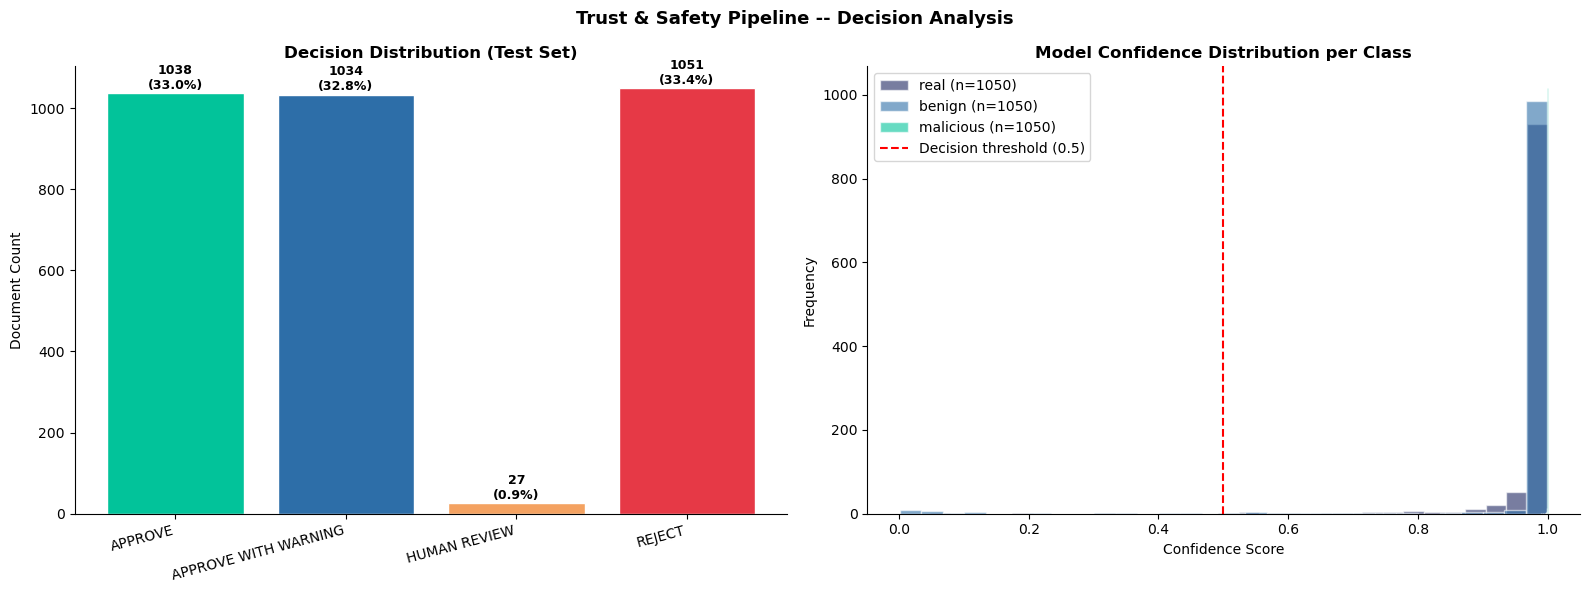

Decision plot saved: C:\adversarial_doc_project\outputs\week5_pipeline_decisions.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Trust & Safety Pipeline -- Decision Analysis",
             fontsize=13, fontweight="bold")

ax = axes[0]
decision_order  = ["APPROVE", "APPROVE WITH WARNING", "HUMAN REVIEW", "REJECT"]
decision_colors = ["#02C39A", "#2D6EA8", "#F4A261", "#E63946"]
counts = [decision_counts.get(d, 0) for d in decision_order]

bars = ax.bar(decision_order, counts, color=decision_colors, edgecolor="white")
ax.set_title("Decision Distribution (Test Set)", fontweight="bold")
ax.set_ylabel("Document Count")
ax.set_xticklabels(decision_order, rotation=15, ha="right")
for b, v in zip(bars, counts):
    pct = v / len(all_decisions) * 100
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 10,
            f"{v}\n({pct:.1f}%)", ha="center", fontsize=9, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)

ax = axes[1]
all_confs_np  = np.array(all_confs)
all_labels_np = np.array(all_labels)
colors = ["#1E2761", "#2D6EA8", "#02C39A"]
for class_idx, (class_name, color) in enumerate(zip(CLASS_LIST, colors)):
    mask = all_labels_np == class_idx
    ax.hist(all_confs_np[mask, class_idx], bins=30, alpha=0.6,
            color=color, label=f"{class_name} (n={mask.sum()})", edgecolor="white")

ax.axvline(x=0.5, color="red", linestyle="--", linewidth=1.5,
           label="Decision threshold (0.5)")
ax.set_title("Model Confidence Distribution per Class", fontweight="bold")
ax.set_xlabel("Confidence Score")
ax.set_ylabel("Frequency")
ax.legend()
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
out = OUTPUTS_DIR / "week5_pipeline_decisions.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Decision plot saved: {out}")


## Step 8 - Per-Type Performance Breakdown

Real documents:
  F1=0.9950  Precision=1.0000  Recall=0.9900  Acc=0.9900

Benign perturbations:
  F1=0.9848  Precision=1.0000  Recall=0.9700  Acc=0.9700

Malicious tampering:
  F1=1.0000  Precision=1.0000  Recall=1.0000  Acc=1.0000



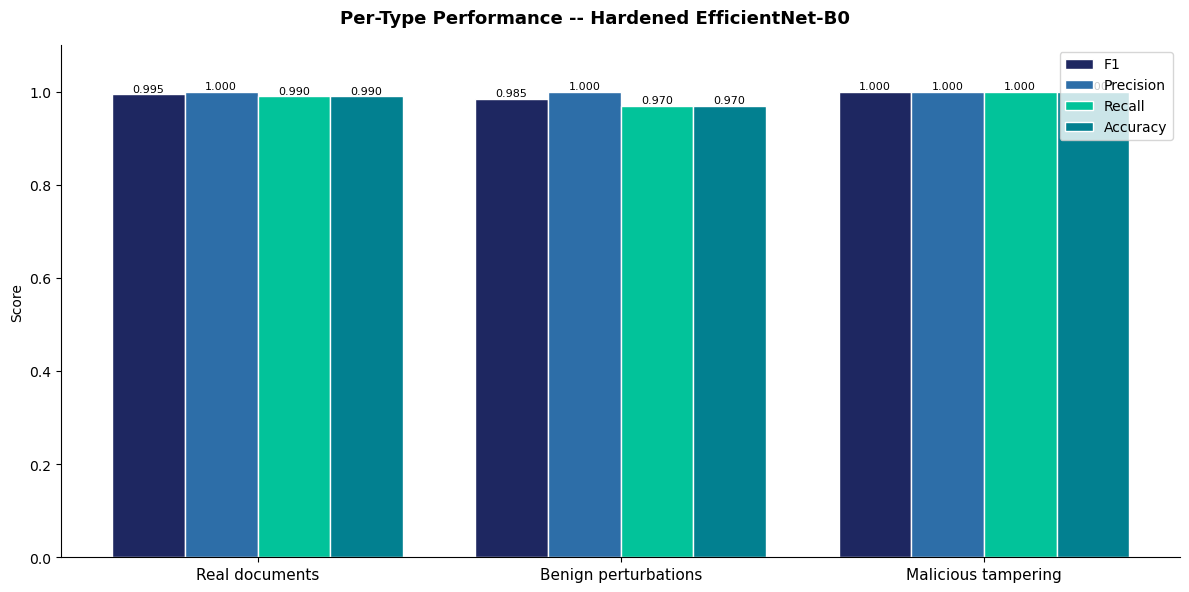

Per-type plot saved: C:\adversarial_doc_project\outputs\week5_per_type_performance.png


In [8]:
aug_test_df = pd.read_csv(SPLITS_DIR / "aug_test.csv")

real_test      = aug_test_df[aug_test_df["label"] == 0]
benign_test    = aug_test_df[aug_test_df["label"] == 1]
malicious_test = aug_test_df[aug_test_df["label"] == 2]

results_per_type = {}

for split_name, split_df, true_label in [
    ("Real documents",       real_test,      0),
    ("Benign perturbations", benign_test,    1),
    ("Malicious tampering",  malicious_test, 2),
]:
    sample = split_df.sample(min(200, len(split_df)), random_state=SEED)
    preds_list  = []
    labels_list = []

    effnet.eval()
    with torch.no_grad():
        for _, row in sample.iterrows():
            try:
                img    = Image.open(row["frame_path"]).convert("RGB")
                tensor = val_transform(img).unsqueeze(0).to(DEVICE)
                pred   = int(effnet(tensor).argmax(dim=1).item())
                preds_list.append(pred)
                labels_list.append(int(row["label"]))
            except Exception:
                continue

    f1   = f1_score(labels_list, preds_list, average="weighted", zero_division=0)
    prec = precision_score(labels_list, preds_list, average="weighted", zero_division=0)
    rec  = recall_score(labels_list, preds_list, average="weighted", zero_division=0)
    acc  = sum(p == l for p, l in zip(preds_list, labels_list)) / max(len(preds_list),1)

    results_per_type[split_name] = {
        "f1": round(f1,4), "precision": round(prec,4),
        "recall": round(rec,4), "accuracy": round(acc,4)
    }
    print(f"{split_name}:")
    print(f"  F1={f1:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  Acc={acc:.4f}\n")

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Per-Type Performance -- Hardened EfficientNet-B0",
             fontsize=13, fontweight="bold")

types   = list(results_per_type.keys())
metrics = ["f1", "precision", "recall", "accuracy"]
colors  = ["#1E2761", "#2D6EA8", "#02C39A", "#028090"]
x       = np.arange(len(types))
width   = 0.2

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = [results_per_type[t][metric] for t in types]
    bars = ax.bar(x + i*width, vals, width, label=metric.capitalize(),
                  color=color, edgecolor="white")
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f"{v:.3f}", ha="center", fontsize=8)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(types, fontsize=11)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.legend()
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
out = OUTPUTS_DIR / "week5_per_type_performance.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Per-type plot saved: {out}")


## Step 9 - Hardened Model Threshold Analysis

In [9]:
full_df      = pd.read_csv(DATA_DIR / "frame_index.csv")
sample_paths = full_df["frame_path"].sample(10, random_state=SEED).tolist()

single_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def get_confidence(model, img_path, transform, device, class_idx=0):
    img    = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)
    return probs[0][class_idx].item()

sweep_configs = {
    "Blur Radius"        : {"values": list(range(1,16,2)),  "label": "Blur kernel size"},
    "Brightness Shift"   : {"values": [round(v,1) for v in np.arange(0,1.1,0.1)], "label": "Brightness limit"},
    "Rotation Angle"     : {"values": list(range(0,46,5)),  "label": "Rotation degrees"},
    "Compression Quality": {"values": list(range(10,101,10)),"label": "JPEG quality"},
}

hardened_results = {}
print("Running threshold sweep on hardened model...")

for name, config in sweep_configs.items():
    print(f"  Sweeping: {name}")
    confs_per_level = []

    for intensity in config["values"]:
        level_confs = []
        for img_path in sample_paths:
            img = cv2.imread(img_path)
            if img is None: continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if name == "Blur Radius":
                k = intensity if intensity % 2 == 1 else intensity+1
                perturbed = cv2.GaussianBlur(img_rgb, (k,k), 0)
            elif name == "Brightness Shift":
                hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
                hsv[:,:,2] = np.clip(hsv[:,:,2]*(1+intensity), 0, 255)
                perturbed = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
            elif name == "Rotation Angle":
                h, w = img_rgb.shape[:2]
                M = cv2.getRotationMatrix2D((w//2,h//2), intensity, 1.0)
                perturbed = cv2.warpAffine(img_rgb, M, (w,h))
            elif name == "Compression Quality":
                _, enc = cv2.imencode(".jpg", img_rgb, [cv2.IMWRITE_JPEG_QUALITY, intensity])
                perturbed = cv2.imdecode(enc, cv2.IMREAD_COLOR)
                perturbed = cv2.cvtColor(perturbed, cv2.COLOR_BGR2RGB)

            tmp = OUTPUTS_DIR / "_tmp.jpg"
            cv2.imwrite(str(tmp), cv2.cvtColor(perturbed, cv2.COLOR_RGB2BGR))
            conf = get_confidence(effnet, tmp, single_transform, DEVICE)
            level_confs.append(conf)

        confs_per_level.append(np.mean(level_confs))

    hardened_results[name] = {
        "values"     : config["values"],
        "confidences": confs_per_level,
        "label"      : config["label"],
    }

if (OUTPUTS_DIR / "_tmp.jpg").exists():
    (OUTPUTS_DIR / "_tmp.jpg").unlink()
print("Threshold sweep complete.")


Running threshold sweep on hardened model...
  Sweeping: Blur Radius
  Sweeping: Brightness Shift
  Sweeping: Rotation Angle
  Sweeping: Compression Quality
Threshold sweep complete.


## Step 10 - Baseline vs Hardened Threshold Comparison

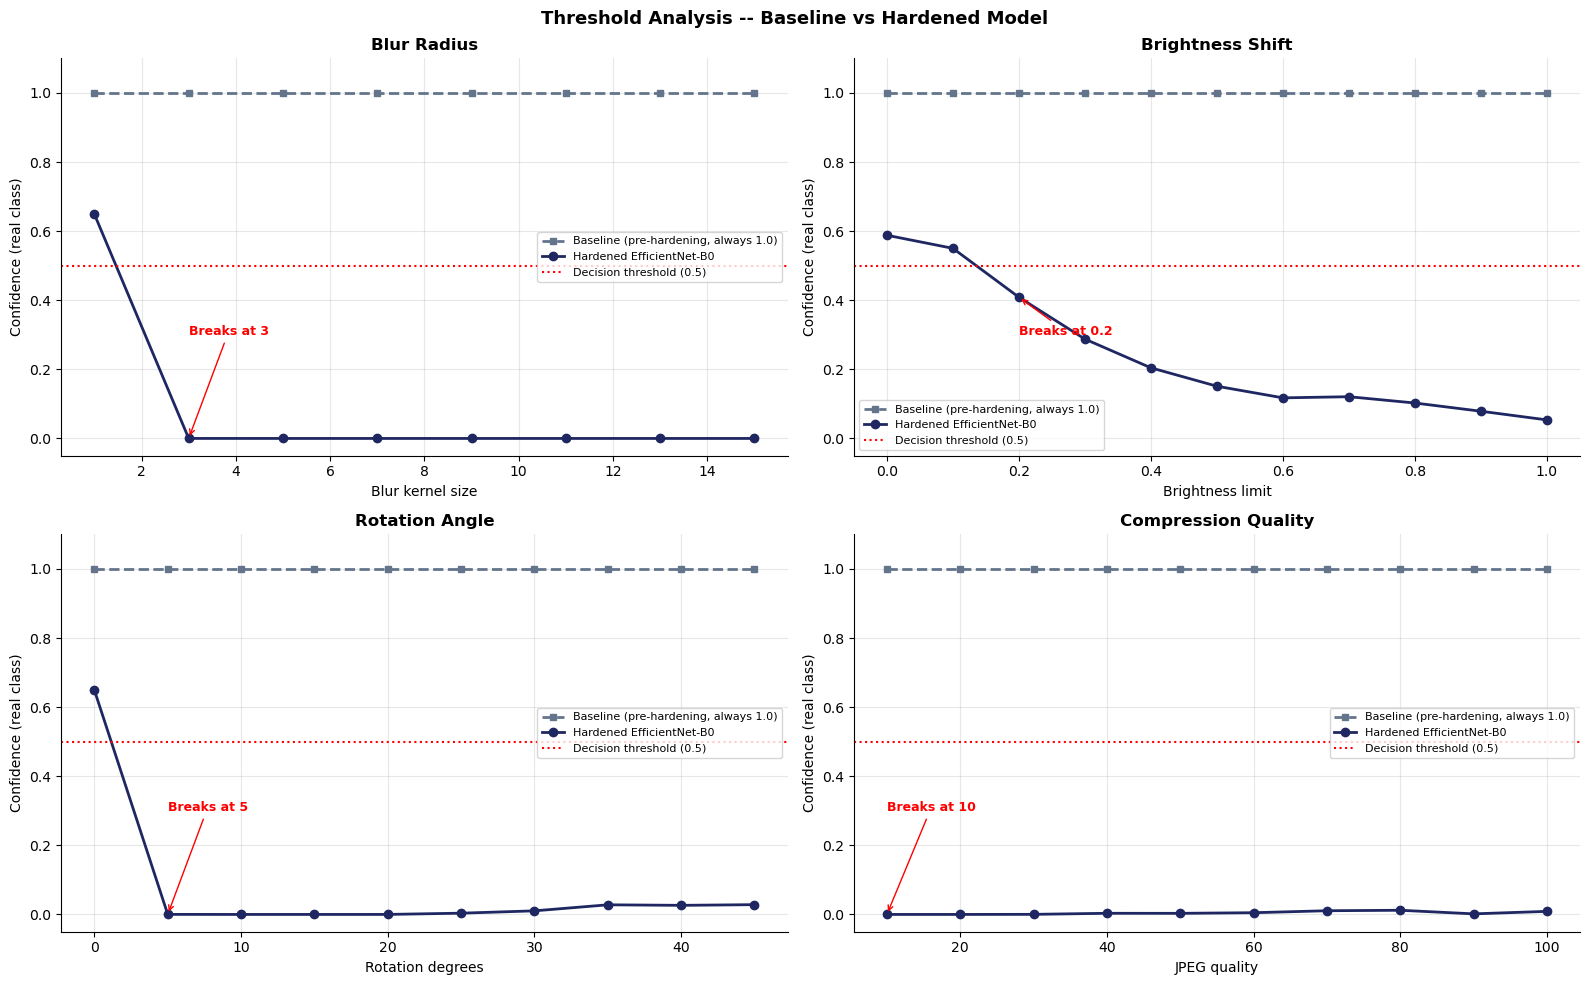

Threshold comparison saved: C:\adversarial_doc_project\outputs\week5_threshold_comparison.png

Breaking Point Summary:
---------------------------------------------
  Blur Radius              : 3
  Brightness Shift         : 0.2
  Rotation Angle           : 5
  Compression Quality      : 10


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Threshold Analysis -- Baseline vs Hardened Model",
             fontsize=13, fontweight="bold")

axes_flat = axes.flatten()

for i, (name, data) in enumerate(hardened_results.items()):
    ax     = axes_flat[i]
    values = data["values"]
    confs  = data["confidences"]

    ax.plot(values, [1.0]*len(values), color="#64748B",
            linestyle="--", linewidth=2, marker="s", markersize=4,
            label="Baseline (pre-hardening, always 1.0)")

    ax.plot(values, confs, color="#1E2761", marker="o",
            linewidth=2, markersize=6, label="Hardened EfficientNet-B0")

    ax.axhline(y=0.5, color="red", linestyle=":", linewidth=1.5,
               label="Decision threshold (0.5)")

    breaking = next((values[j] for j,c in enumerate(confs) if c < 0.5), None)
    if breaking:
        bp_conf = confs[values.index(breaking)]
        ax.annotate(f"Breaks at {breaking}",
                    xy=(breaking, bp_conf), xytext=(breaking, 0.3),
                    arrowprops=dict(arrowstyle="->", color="red"),
                    color="red", fontsize=9, fontweight="bold")

    ax.set_title(name, fontweight="bold")
    ax.set_xlabel(data["label"])
    ax.set_ylabel("Confidence (real class)")
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(alpha=0.3)

plt.tight_layout()
out = OUTPUTS_DIR / "week5_threshold_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Threshold comparison saved: {out}")

print("\nBreaking Point Summary:")
print("-" * 45)
for name, data in hardened_results.items():
    bp = next((data["values"][j] for j,c in enumerate(data["confidences"]) if c < 0.5), "Never")
    print(f"  {name:<25}: {bp}")


## Step 11 - Complete Results Summary

In [11]:
lines = [
    "=" * 65,
    "COMPLETE PROJECT RESULTS SUMMARY",
    "Adversarial Robustness Testing & Trust Safety Pipeline",
    "=" * 65,
    "",
    "DATASET",
    "-------",
    "  MIDV-500 + MIDV-2019 combined",
    "  Total clips     : 700",
    "  Total frames    : 7,000 (original) -> 21,000 (augmented)",
    "  Classes         : real=7,000 | benign=7,000 | malicious=7,000",
    "  Split           : 70% train | 15% val | 15% test (clip-level)",
    "",
    "MODEL PERFORMANCE",
    "-----------------",
    "  Stage                     F1 Score   Accuracy",
    "  Baseline (pre-hardening)  0.1826     0.3400",
    "  Hardened EfficientNet-B0  0.9892     0.9892",
    "  Hardened ResNet18         0.9832     0.9832",
    "  Improvement               +0.8066    +0.6492",
    "",
    "PER-CLASS (Hardened EfficientNet-B0)",
    "-------------------------------------",
    "  Real      : Precision=0.97  Recall=1.00  F1=0.98",
    "  Benign    : Precision=1.00  Recall=0.97  F1=0.98",
    "  Malicious : Precision=1.00  Recall=1.00  F1=1.00",
    "",
    "CRITICAL SAFETY FINDING",
    "-----------------------",
    "  Malicious documents NEVER misclassified as real.",
    "  Zero false negatives on fraud detection.",
    "",
]
for line in lines:
    print(line)

print("TRUST & SAFETY DECISIONS (on 3,150 test documents)")
print("----------------------------------------------------")
for decision, count in decision_counts.items():
    pct = count / len(all_decisions) * 100
    print(f"  {decision:<25}: {count:>5} ({pct:.1f}%)")

print()
print("=" * 65)
print("PROJECT STATUS: COMPLETE")
print("=" * 65)


COMPLETE PROJECT RESULTS SUMMARY
Adversarial Robustness Testing & Trust Safety Pipeline

DATASET
-------
  MIDV-500 + MIDV-2019 combined
  Total clips     : 700
  Total frames    : 7,000 (original) -> 21,000 (augmented)
  Classes         : real=7,000 | benign=7,000 | malicious=7,000
  Split           : 70% train | 15% val | 15% test (clip-level)

MODEL PERFORMANCE
-----------------
  Stage                     F1 Score   Accuracy
  Baseline (pre-hardening)  0.1826     0.3400
  Hardened EfficientNet-B0  0.9892     0.9892
  Hardened ResNet18         0.9832     0.9832
  Improvement               +0.8066    +0.6492

PER-CLASS (Hardened EfficientNet-B0)
-------------------------------------
  Real      : Precision=0.97  Recall=1.00  F1=0.98
  Benign    : Precision=1.00  Recall=0.97  F1=0.98
  Malicious : Precision=1.00  Recall=1.00  F1=1.00

CRITICAL SAFETY FINDING
-----------------------
  Malicious documents NEVER misclassified as real.
  Zero false negatives on fraud detection.

TRUST & S